In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
df = pd.read_csv('/content/mobile_sales_data.csv')

In [104]:
print(df.shape)

(50000, 16)


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product                  50000 non-null  object
 1   Brand                    50000 non-null  object
 2   Product Code             50000 non-null  object
 3   Product Specification    50000 non-null  object
 4   Price                    50000 non-null  int64 
 5   Inward Date              50000 non-null  object
 6   Dispatch Date            50000 non-null  object
 7   Quantity Sold            50000 non-null  int64 
 8   Customer Name            50000 non-null  object
 9   Customer Location        50000 non-null  object
 10  Region                   50000 non-null  object
 11  Core Specification       25017 non-null  object
 12  Processor Specification  50000 non-null  object
 13  RAM                      50000 non-null  object
 14  ROM                      50000 non-nul

In [106]:
df.describe()

,Price,Quantity Sold
count,50000.000000,50000.00000
mean,102641.407080,5.51378
std,56363.550361,2.88101
min,5008.000000,1.00000
25%,53487.000000,3.00000
50%,103072.000000,6.00000
75%,151396.250000,8.00000
max,199999.000000,10.00000


In [107]:
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,NaN,Snapdragon 7 Gen,12GB,128GB,NaN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,NaN,MediaTek Dimensity,8GB,256GB,NaN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


In [108]:
df.tail()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
49995,Laptop,Motorola,8C187637,Pick build kind teach mean each camera.,170385,2024-03-02,2024-04-11,6,Sara Gomez,Sylviatown,North,i3,i3,16GB,512GB,2TB
49996,Laptop,HP,0DA9E4D3,Outside policy treat he opportunity pattern.,193133,2025-01-19,2025-01-20,4,Raymond Clark,Chrismouth,West,i7,i7,8GB,1TB,512GB
49997,Laptop,Toshiba,CAD89A93,Test floor tax together out adult discover own...,66502,2024-01-16,2024-03-05,6,Joseph Martin,Huntfurt,North,i5,i5,4GB,64GB,2TB
49998,Mobile Phone,Lenovo,78566C17,Away also magazine receive such lay.,158883,2023-05-15,2023-05-25,2,Gabrielle Barnett,Heidiberg,North,NaN,Snapdragon 7s,12GB,1TB,NaN
49999,Laptop,Asus,9C3FC57C,Role ahead common listen idea few blood half.,86483,2023-08-29,2023-10-26,7,Robert Sampson,West Elizabethchester,East,i7,i7,12GB,128GB,256GB


In [109]:
missing = df.isna().sum().sort_values(ascending=False)

In [110]:
print(missing)

SSD                        24983
Core Specification         24983
Product                        0
Brand                          0
Price                          0
Inward Date                    0
Product Code                   0
Product Specification          0
Quantity Sold                  0
Dispatch Date                  0
Customer Location              0
Customer Name                  0
Region                         0
Processor Specification        0
RAM                            0
ROM                            0
dtype: int64


In [111]:
missing_pct = (missing / len(df) * 100).round(2)
print(missing_pct)

SSD                        49.97
Core Specification         49.97
Product                     0.00
Brand                       0.00
Price                       0.00
Inward Date                 0.00
Product Code                0.00
Product Specification       0.00
Quantity Sold               0.00
Dispatch Date               0.00
Customer Location           0.00
Customer Name               0.00
Region                      0.00
Processor Specification     0.00
RAM                         0.00
ROM                         0.00
dtype: float64


In [112]:
missing_table = pd.concat([missing, missing_pct], axis=1, keys=['missing_count','missing_pct'])
print(missing_table)

                         missing_count  missing_pct
SSD                              24983        49.97
Core Specification               24983        49.97
Product                              0         0.00
Brand                                0         0.00
Price                                0         0.00
Inward Date                          0         0.00
Product Code                         0         0.00
Product Specification                0         0.00
Quantity Sold                        0         0.00
Dispatch Date                        0         0.00
Customer Location                    0         0.00
Customer Name                        0         0.00
Region                               0         0.00
Processor Specification              0         0.00
RAM                                  0         0.00
ROM                                  0         0.00


In [113]:
if 'Core Specification' in df.columns:
    missing_before = df['Core Specification'].isna().sum()
    df['Core Specification'] = df['Core Specification'].fillna('UNKNOWN')
    print(f"Core Specification: filled {missing_before} missing values with 'UNKNOWN'.")

Core Specification: filled 24983 missing values with 'UNKNOWN'.


In [114]:
if 'SSD' in df.columns:
    missing_before = df['SSD'].isna().sum()
    df['SSD'] = df['SSD'].fillna('UNKNOWN')
    print(f"SSD: filled {missing_before} missing values with 'UNKNOWN'.")

SSD: filled 24983 missing values with 'UNKNOWN'.


In [115]:
for col in ['Inward Date', 'Dispatch Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [116]:
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,Region,Core Specification,Processor Specification,RAM,ROM,SSD
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,Central,UNKNOWN,Snapdragon 7 Gen,12GB,128GB,UNKNOWN
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,South,Ryzen 5,Ryzen 5,8GB,512GB,256GB
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,Central,UNKNOWN,MediaTek Dimensity,8GB,256GB,UNKNOWN
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,South,i7,i7,12GB,64GB,2TB
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,East,i7,i7,8GB,128GB,2TB


In [117]:
print("Full duplicate rows:", df.duplicated().sum())
if 'Product Code' in df.columns:
    print("Duplicate Product Code:", df['Product Code'].duplicated().sum())

Full duplicate rows: 0
Duplicate Product Code: 0


In [118]:
df['inward_year'] = df['Inward Date'].dt.year
df['inward_month'] = df['Inward Date'].dt.month
df['inward_weekday'] = df['Inward Date'].dt.day_name()

In [119]:
df['dispatch_year'] = df['Dispatch Date'].dt.year
df['dispatch_month'] = df['Dispatch Date'].dt.month
df['dispatch_weekday'] = df['Dispatch Date'].dt.day_name()

In [120]:
df['time_to_dispatch'] = (df['Dispatch Date'] - df['Inward Date']).dt.days

In [121]:
df.head()

,Product,Brand,Product Code,Product Specification,Price,Inward Date,Dispatch Date,Quantity Sold,Customer Name,Customer Location,...,RAM,ROM,SSD,inward_year,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,...,12GB,128GB,UNKNOWN,2023,8,Wednesday,2023,8,Thursday,1
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,...,8GB,512GB,256GB,2023,10,Tuesday,2023,10,Friday,3
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,...,8GB,256GB,UNKNOWN,2025,3,Wednesday,2025,3,Thursday,1
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,...,12GB,64GB,2TB,2024,2,Tuesday,2024,3,Wednesday,50
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,...,8GB,128GB,2TB,2023,8,Thursday,2023,9,Sunday,31


In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product                  50000 non-null  object        
 1   Brand                    50000 non-null  object        
 2   Product Code             50000 non-null  object        
 3   Product Specification    50000 non-null  object        
 4   Price                    50000 non-null  int64         
 5   Inward Date              50000 non-null  datetime64[ns]
 6   Dispatch Date            50000 non-null  datetime64[ns]
 7   Quantity Sold            50000 non-null  int64         
 8   Customer Name            50000 non-null  object        
 9   Customer Location        50000 non-null  object        
 10  Region                   50000 non-null  object        
 11  Core Specification       50000 non-null  object        
 12  Processor Specification  50000 n

In [123]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [124]:
df.head()

,product,brand,product_code,product_specification,price,inward_date,dispatch_date,quantity_sold,customer_name,customer_location,...,ram,rom,ssd,inward_year,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,...,12GB,128GB,UNKNOWN,2023,8,Wednesday,2023,8,Thursday,1
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,...,8GB,512GB,256GB,2023,10,Tuesday,2023,10,Friday,3
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,...,8GB,256GB,UNKNOWN,2025,3,Wednesday,2025,3,Thursday,1
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,...,12GB,64GB,2TB,2024,2,Tuesday,2024,3,Wednesday,50
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,...,8GB,128GB,2TB,2023,8,Thursday,2023,9,Sunday,31


In [125]:
df['total_sales'] = df['price'] * df['quantity_sold']

In [126]:
df.head()

,product,brand,product_code,product_specification,price,inward_date,dispatch_date,quantity_sold,customer_name,customer_location,...,rom,ssd,inward_year,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,...,128GB,UNKNOWN,2023,8,Wednesday,2023,8,Thursday,1,471420
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,...,512GB,256GB,2023,10,Tuesday,2023,10,Friday,3,44613
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,...,256GB,UNKNOWN,2025,3,Wednesday,2025,3,Thursday,1,799130
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,...,64GB,2TB,2024,2,Tuesday,2024,3,Wednesday,50,20911
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,...,128GB,2TB,2023,8,Thursday,2023,9,Sunday,31,279328


In [127]:
df['cost_price'] = df['price'] * 0.95
df['profit'] = df['price'] - df['cost_price']

In [128]:
df.head()

,product,brand,product_code,product_specification,price,inward_date,dispatch_date,quantity_sold,customer_name,customer_location,...,inward_year,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,2023-08-02,2023-08-03,6,William Hess,South Kelsey,...,2023,8,Wednesday,2023,8,Thursday,1,471420,74641.50,3928.50
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,2023-10-03,2023-10-06,1,Larry Smith,North Lisa,...,2023,10,Tuesday,2023,10,Friday,3,44613,42382.35,2230.65
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,2025-03-19,2025-03-20,5,Leah Copeland,South Todd,...,2025,3,Wednesday,2025,3,Thursday,1,799130,151834.70,7991.30
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,2024-02-06,2024-03-27,1,Dan Kirby,New Jordanmouth,...,2024,2,Tuesday,2024,3,Wednesday,50,20911,19865.45,1045.55
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,2023-08-10,2023-09-10,4,Dean Martin,Keithton,...,2023,8,Thursday,2023,9,Sunday,31,279328,66340.40,3491.60


In [129]:
df['profit_margin'] = (df['profit'] / df['total_sales']) * 100

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   product                  50000 non-null  object        
 1   brand                    50000 non-null  object        
 2   product_code             50000 non-null  object        
 3   product_specification    50000 non-null  object        
 4   price                    50000 non-null  int64         
 5   inward_date              50000 non-null  datetime64[ns]
 6   dispatch_date            50000 non-null  datetime64[ns]
 7   quantity_sold            50000 non-null  int64         
 8   customer_name            50000 non-null  object        
 9   customer_location        50000 non-null  object        
 10  region                   50000 non-null  object        
 11  core_specification       50000 non-null  object        
 12  processor_specification  50000 n

In [131]:
df = df.drop(columns=['inward_date', 'dispatch_date'])

In [132]:
df.head()

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,6,William Hess,South Kelsey,Central,UNKNOWN,...,8,Wednesday,2023,8,Thursday,1,471420,74641.50,3928.50,0.833333
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,1,Larry Smith,North Lisa,South,Ryzen 5,...,10,Tuesday,2023,10,Friday,3,44613,42382.35,2230.65,5.000000
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,5,Leah Copeland,South Todd,Central,UNKNOWN,...,3,Wednesday,2025,3,Thursday,1,799130,151834.70,7991.30,1.000000
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,1,Dan Kirby,New Jordanmouth,South,i7,...,2,Tuesday,2024,3,Wednesday,50,20911,19865.45,1045.55,5.000000
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,4,Dean Martin,Keithton,East,i7,...,8,Thursday,2023,9,Sunday,31,279328,66340.40,3491.60,1.250000


In [133]:
df['brand'] = df['brand'].str.strip().str.title()
df['core_specification'] = df['core_specification'].str.strip().str.upper()
df.head()

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,6,William Hess,South Kelsey,Central,UNKNOWN,...,8,Wednesday,2023,8,Thursday,1,471420,74641.50,3928.50,0.833333
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,1,Larry Smith,North Lisa,South,RYZEN 5,...,10,Tuesday,2023,10,Friday,3,44613,42382.35,2230.65,5.000000
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,5,Leah Copeland,South Todd,Central,UNKNOWN,...,3,Wednesday,2025,3,Thursday,1,799130,151834.70,7991.30,1.000000
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,1,Dan Kirby,New Jordanmouth,South,I7,...,2,Tuesday,2024,3,Wednesday,50,20911,19865.45,1045.55,5.000000
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,4,Dean Martin,Keithton,East,I7,...,8,Thursday,2023,9,Sunday,31,279328,66340.40,3491.60,1.250000


In [134]:
df[df['price'] < 0]
df[df['quantity_sold'] < 0]

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin


In [135]:
df[df['price'] == 0]
df[df['quantity_sold'] == 0]

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin


In [136]:
df[['price', 'quantity_sold']].describe()

,price,quantity_sold
count,50000.000000,50000.00000
mean,102641.407080,5.51378
std,56363.550361,2.88101
min,5008.000000,1.00000
25%,53487.000000,3.00000
50%,103072.000000,6.00000
75%,151396.250000,8.00000
max,199999.000000,10.00000


In [137]:
df[df['price'] > df['price'].quantile(0.75) * 2]

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin


In [138]:
df[df['price'] < df['price'].quantile(0.25) / 2]

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,1,Dan Kirby,New Jordanmouth,South,I7,...,2,Tuesday,2024,3,Wednesday,50,20911,19865.45,1045.55,5.000000
6,Mobile Phone,Dell,14932CAE,Could before almost wind couple evening perfor...,11670,6,Nicole Gonzalez,South Miguel,North,UNKNOWN,...,10,Tuesday,2023,10,Monday,6,70020,11086.50,583.50,0.833333
7,Laptop,Apple,D58FF785,Reality sea weight thing newspaper good next g...,15041,1,Danielle Smith,North Travis,South,I7,...,10,Sunday,2023,12,Wednesday,52,15041,14288.95,752.05,5.000000
24,Laptop,Lenovo,552EAB5F,Structure road unit theory inside station war ...,9395,9,Megan Valenzuela,North Raymondtown,South,RYZEN 5,...,2,Thursday,2025,4,Wednesday,48,84555,8925.25,469.75,0.555556
29,Laptop,Redmi,9A61C658,Base hour run to heart building wonder seven f...,11675,6,Kyle Wright,Vaughanchester,South,I9,...,9,Saturday,2023,10,Friday,34,70050,11091.25,583.75,0.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49962,Laptop,Vivo,8AAA9530,Seven drug book them relationship wrong left r...,19095,6,Jessica Dominguez MD,Bartonbury,West,I5,...,5,Tuesday,2024,7,Saturday,60,114570,18140.25,954.75,0.833333
49964,Laptop,Acer,14B02E52,Forget my down doctor education line buy song.,18772,10,Travis Lewis,East Dawnburgh,Central,RYZEN 3,...,5,Sunday,2023,7,Saturday,48,187720,17833.40,938.60,0.500000
49968,Mobile Phone,Motorola,EEF6C6F6,Probably against tell both item about life esp...,22112,3,Heidi Whitehead,East Justinstad,West,UNKNOWN,...,4,Saturday,2023,6,Sunday,57,66336,21006.40,1105.60,1.666667
49978,Laptop,Huawei,003DC8DF,Begin painting end image fear end gun natural.,17781,5,Sandra Williamson,Julieside,West,I9,...,4,Sunday,2023,5,Monday,43,88905,16891.95,889.05,1.000000


In [139]:
df.head()

,product,brand,product_code,product_specification,price,quantity_sold,customer_name,customer_location,region,core_specification,...,inward_month,inward_weekday,dispatch_year,dispatch_month,dispatch_weekday,time_to_dispatch,total_sales,cost_price,profit,profit_margin
0,Mobile Phone,Motorola,88EB4558,Site candidate activity company there bit insi...,78570,6,William Hess,South Kelsey,Central,UNKNOWN,...,8,Wednesday,2023,8,Thursday,1,471420,74641.50,3928.50,0.833333
1,Laptop,Oppo,416DFEEB,Beat put care fight affect address his.,44613,1,Larry Smith,North Lisa,South,RYZEN 5,...,10,Tuesday,2023,10,Friday,3,44613,42382.35,2230.65,5.000000
2,Mobile Phone,Samsung,9F975B08,Energy special low seven place audience.,159826,5,Leah Copeland,South Todd,Central,UNKNOWN,...,3,Wednesday,2025,3,Thursday,1,799130,151834.70,7991.30,1.000000
3,Laptop,Sony,73D2A7CC,Friend record hard contain minute we role sea ...,20911,1,Dan Kirby,New Jordanmouth,South,I7,...,2,Tuesday,2024,3,Wednesday,50,20911,19865.45,1045.55,5.000000
4,Laptop,Microsoft,CCE0B80D,Program recently feeling save tree hotel people.,69832,4,Dean Martin,Keithton,East,I7,...,8,Thursday,2023,9,Sunday,31,279328,66340.40,3491.60,1.250000


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product                  50000 non-null  object 
 1   brand                    50000 non-null  object 
 2   product_code             50000 non-null  object 
 3   product_specification    50000 non-null  object 
 4   price                    50000 non-null  int64  
 5   quantity_sold            50000 non-null  int64  
 6   customer_name            50000 non-null  object 
 7   customer_location        50000 non-null  object 
 8   region                   50000 non-null  object 
 9   core_specification       50000 non-null  object 
 10  processor_specification  50000 non-null  object 
 11  ram                      50000 non-null  object 
 12  rom                      50000 non-null  object 
 13  ssd                      50000 non-null  object 
 14  inward_year           

In [141]:
df.to_csv("Cleaned_Mobile_sales.csv",index=False)
print("Cleaned dataset saved")

Cleaned dataset saved


In [142]:
import seaborn as sns
import matplotlib.pyplot as plt

In [143]:
import sqlite3
conn = sqlite3.connect(':memory:')
df.to_sql('mobile_sales', conn, index=False, if_exists='replace')

50000

       brand  total_sales
0     Google   1514617084
1      Nokia   1473167125
2      Apple   1470242666
3    Toshiba   1454585835
4       Sony   1442582351
5    Samsung   1436721278
6      Redmi   1432172989
7  Microsoft   1430065277
8   Motorola   1420578610
9       Acer   1419570397


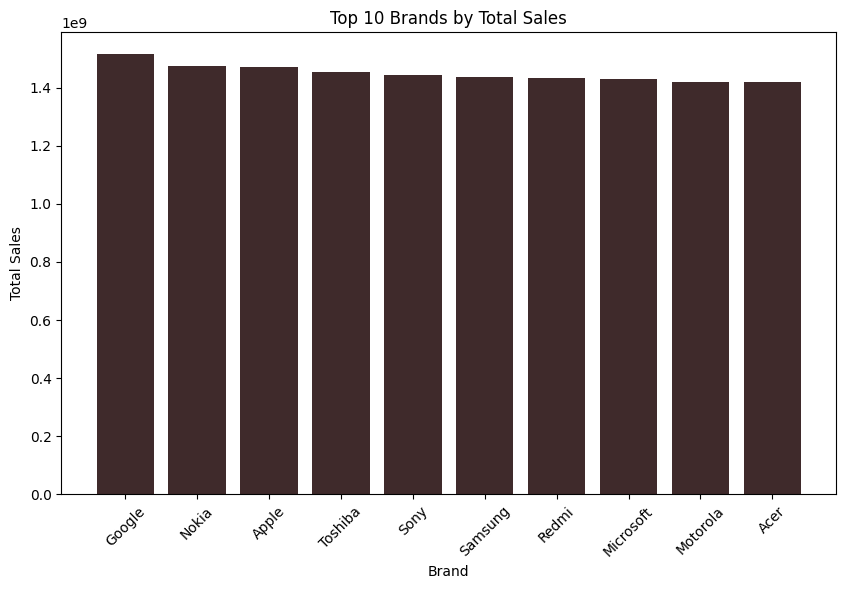

In [144]:
query = """
SELECT brand, SUM(total_sales) AS total_sales
FROM mobile_sales
GROUP BY brand
ORDER BY total_sales DESC
LIMIT 10;
"""
result = pd.read_sql(query, conn)
print(result)

plt.figure(figsize=(10,6))
plt.bar(result['brand'], result['total_sales'], color='#3F2A2B')
plt.title('Top 10 Brands by Total Sales')
plt.xlabel('Brand')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

    region  total_profit
0     West   53100169.05
1    South   51397832.65
2    North   50893700.15
3  Central   50813379.80
4     East   50398436.05


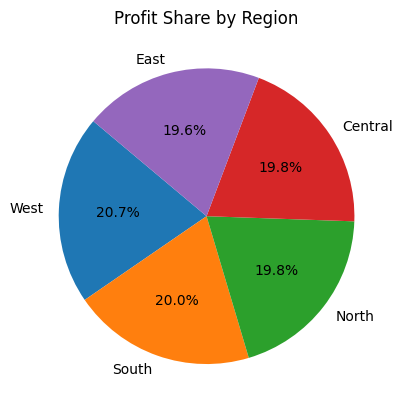

In [145]:
query = """
SELECT region, SUM(profit) AS total_profit
FROM mobile_sales
GROUP BY region
ORDER BY total_profit DESC;
"""
result = pd.read_sql(query, conn)
print(result)

plt.pie(result['total_profit'], labels=result['region'], autopct='%1.1f%%', startangle=140)
plt.title('Profit Share by Region')
plt.show()

        brand      avg_price
0       Nokia  104432.583431
1      Google  104308.973441
2     Toshiba  104224.778474
3   Microsoft  103841.411070
4       Apple  103728.825663
5        Dell  103548.635318
6     Samsung  103383.020328
7       Redmi  102836.591143
8    Motorola  102728.754732
9      Lenovo  102576.930797
10       Acer  102558.290565
11       Sony  102537.992148
12       Iqoo  102460.867045
13         Hp  101987.899019
14     Huawei  101655.439728
15       Vivo  101623.636400
16     Realme  101430.044845
17       Asus  101306.509739
18    Oneplus  101197.089335
19       Oppo  100168.877642


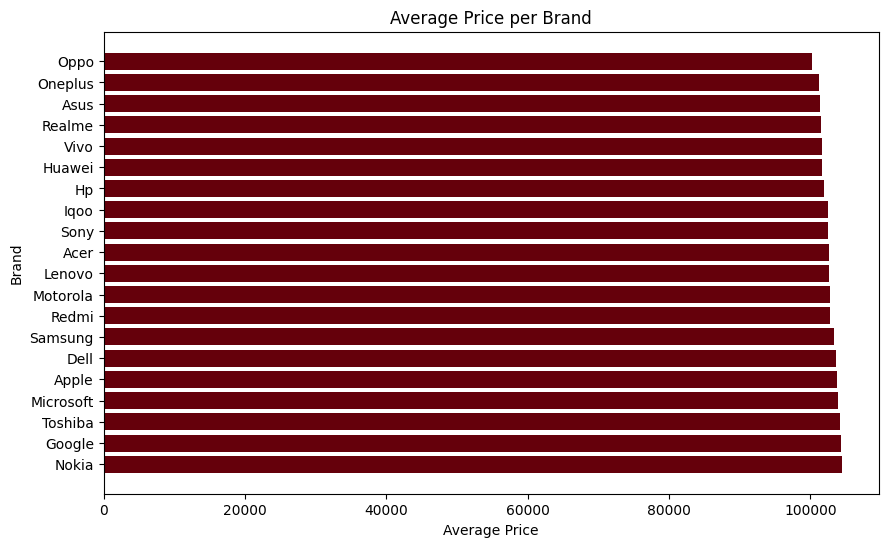

In [146]:
query = """
SELECT brand, AVG(price) AS avg_price
FROM mobile_sales
GROUP BY brand
ORDER BY avg_price DESC;
"""
result = pd.read_sql(query, conn)
print(result)

plt.figure(figsize=(10,6))
plt.barh(result['brand'], result['avg_price'], color='#65000b')
plt.title('Average Price per Brand')
plt.xlabel('Average Price')
plt.ylabel('Brand')
plt.show()

    inward_month  monthly_sales
0              1     2453169829
1              2     2269838033
2              3     2397872628
3              4     2355658187
4              5     2299376105
5              6     2248826294
6              7     2466506758
7              8     2360415239
8              9     2333218563
9             10     2423136936
10            11     2314248366
11            12     2356814184


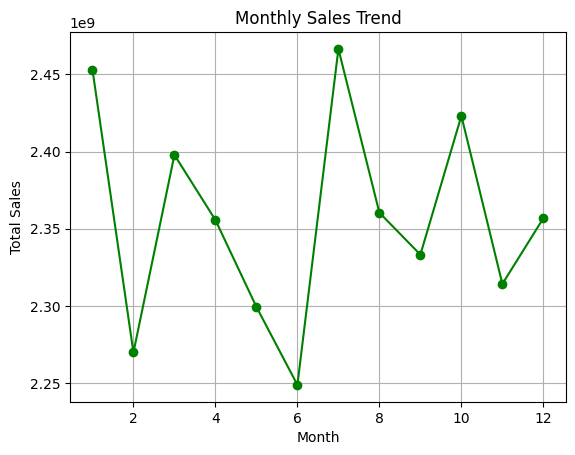

In [147]:
query = """
SELECT inward_month, SUM(total_sales) AS monthly_sales
FROM mobile_sales
GROUP BY inward_month
ORDER BY inward_month;
"""
result = pd.read_sql(query, conn)
print(result)

plt.plot(result['inward_month'], result['monthly_sales'], marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

    price
0   78570
1   44613
2  159826
3   20911
4   69832


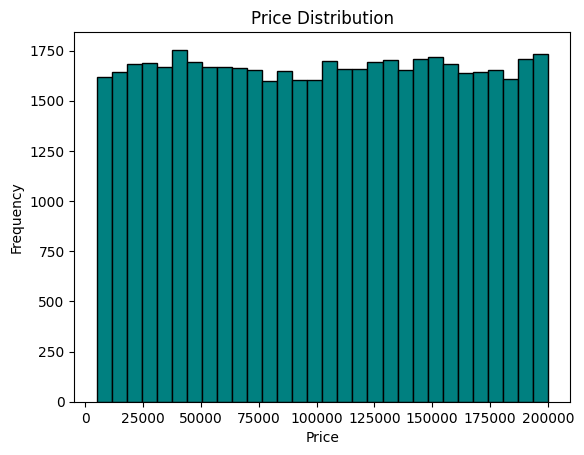

In [148]:
query = "SELECT price FROM mobile_sales;"
result = pd.read_sql(query, conn)
print(result.head())

plt.hist(result['price'], bins=30, color='teal', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

   cost_price   profit
0    74641.50  3928.50
1    42382.35  2230.65
2   151834.70  7991.30
3    19865.45  1045.55
4    66340.40  3491.60


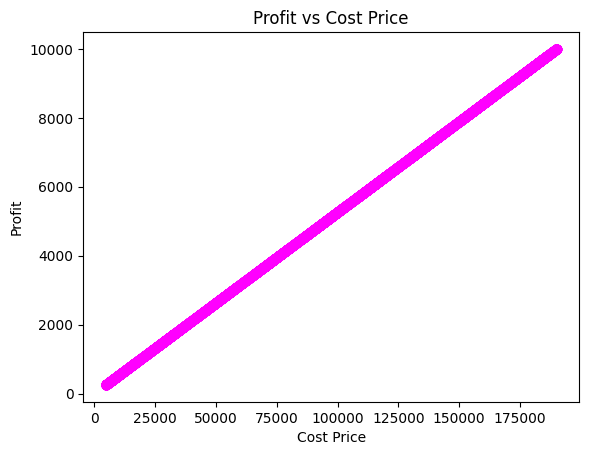

In [149]:
query = "SELECT cost_price, profit FROM mobile_sales;"
result = pd.read_sql(query, conn)
print(result.head())

plt.scatter(result['cost_price'], result['profit'], alpha=0.5, color='magenta')
plt.title('Profit vs Cost Price')
plt.xlabel('Cost Price')
plt.ylabel('Profit')
plt.show()

                  price  quantity_sold  total_sales    profit
price          1.000000      -0.002220     0.677163  1.000000
quantity_sold -0.002220       1.000000     0.643921 -0.002220
total_sales    0.677163       0.643921     1.000000  0.677163
profit         1.000000      -0.002220     0.677163  1.000000


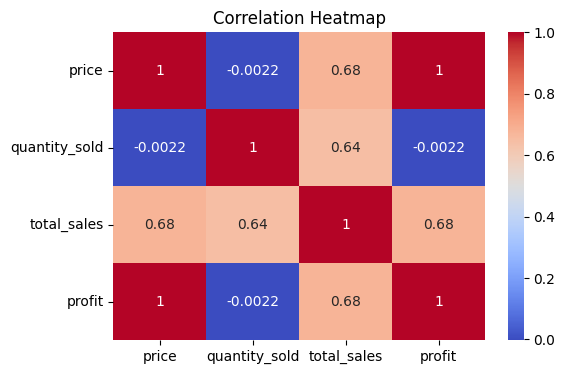

In [150]:
corr = df[['price','quantity_sold','total_sales','profit']].corr()
print(corr)

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

     brand  avg_profit_margin
0     Asus           1.507218
1  Oneplus           1.506426
2     Oppo           1.505610
3  Toshiba           1.497610
4     Acer           1.497463


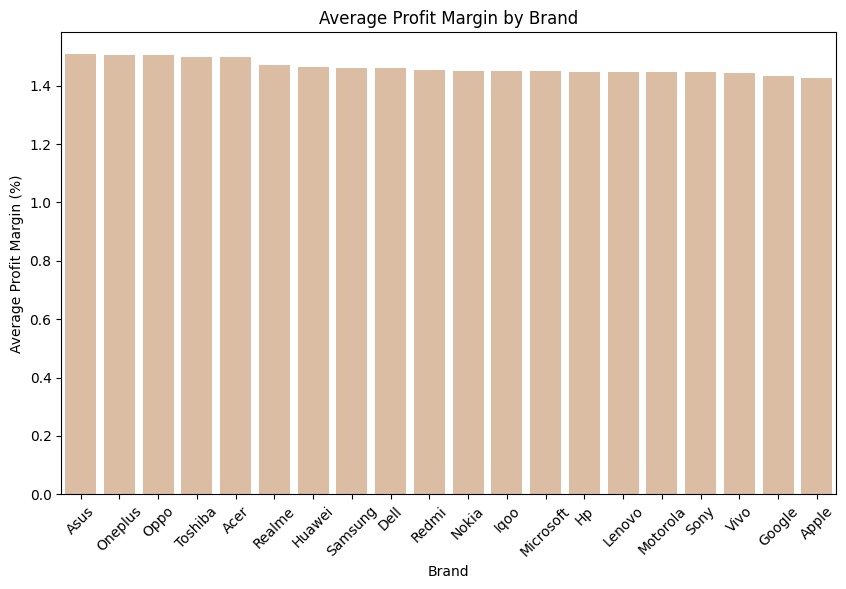

In [151]:
query = """
SELECT brand, AVG(profit_margin) AS avg_profit_margin
FROM mobile_sales
GROUP BY brand
ORDER BY avg_profit_margin DESC;
"""
result = pd.read_sql(query, conn)
print(result.head())

plt.figure(figsize=(10,6))
sns.barplot(x="brand", y="avg_profit_margin", data=result, color="#E3BC9A")
plt.title("Average Profit Margin by Brand")
plt.xlabel("Brand")
plt.ylabel("Average Profit Margin (%)")
plt.xticks(rotation=45)
plt.show()